# **OBJETIVO**: Predecir la nota media del hotel a partir de las reseñas de sus clientes.

**Dataset**: 60.000 reseñas · 12 hoteles  
**Columnas clave**: comentario_general, positivo, negativo, nota (0–10), nota_media_resenas

---

## Paso 0 — EDA (Análisis exploratorio)
Analizamos la distribución de notas, nulos y estructura de los dos dataframes.

- **Resultado**: Sesgo fuerte hacia notas altas (media=8.49, mediana=9.0, 88% de reseñas con nota ≥ 7)
- **Decisión**: reformulamos el problema como clasificación en 3 clases con pesos balanceados

---

## Paso 1 — Análisis de sentimiento sin entrenar (pysentimiento)
Aplicamos un modelo preentrenado sobre las columnas positivo, negativo y comentario_general por separado.

- **Entra**: texto de cada reseña (60.000 filas)
- **Sale**: score POS/NEG/NEU por reseña · correlación score ↔ nota real · perfil de sentimiento por hotel
- **Objetivo**: entender si el sentimiento del texto explica la nota, antes de entrenar nada

---

## Paso 2 — Modelo predictivo con BETO (fine-tuning)
Fine-tuning de bert-base-spanish-wwm-cased usando el texto como input y la nota como target.  
Clasificación en 3 categorías por el sesgo detectado en el Paso 0:

- Clase 0 → nota ≤ 6 (baja, ~8% del dataset)
- Clase 1 → nota 7–8 (media, ~27%)
- Clase 2 → nota 9–10 (alta, ~65%)

Entrenamos con pesos de clase balanceados para que el modelo no ignore las notas bajas.

- **Entra**: texto concatenado [positivo] + [negativo] + [general] · etiqueta clase 0/1/2
- **Sale**: modelo entrenado · Accuracy · F1-macro · matriz de confusión · predicción por reseña

---

## Paso 3 — Agregación por hotel y conclusiones
Las predicciones individuales del Paso 2 se agregan por hotel y se comparan con la nota oficial.

- **Entra**: predicciones del Paso 2 agrupadas por hotel (12 hoteles)
- **Sale**: score agregado por hotel · comparación vs nota_media_resenas · correlación de Spearman
- **Conclusión**: ¿explica el sentimiento de las reseñas la nota oficial del hotel?

# ***IMPORTANTE***: # <----------- INDICA LAS CELDAS NECESARIAS PARA CUALQUIER PASO (POR SI QUEREMOS NO EJECUTARLO TODO:)

In [2]:
!pip install pysentimiento -q # <-------INSTALAR LA PRIMERA VEZ

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 21.5 MB/s eta 0:00:00


In [3]:
!pip install transformers datasets torch -q # <-------INSTALAR LA PRIMERA VEZ

In [20]:
# <-----------
#LIBRERÍAS:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from pysentimiento import create_analyzer
from tqdm import tqdm
tqdm.pandas()
import os
from scipy import stats
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from torch.utils.data import Dataset
from transformers import AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW  # ← desde torch, no transformers
from transformers import get_scheduler
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from scipy import stats
from sklearn.linear_model import LinearRegression

In [6]:
# <-----------
# Cargamos los datos:
df_comentarios = pd.read_csv("/content/df_comentarios_traducidos_final.csv") # <-CUIDADO CON LA RUTA
df_hoteles     = pd.read_csv("/content/df_hoteles_vlc_info.csv") # <-CUIDADO CON LA RUTA

print("COMENTARIOS")
print(f"Filas: {df_comentarios.shape[0]} | Columnas: {df_comentarios.shape[1]}")
print(df_comentarios.dtypes)

print("\nHOTELES")
print(f"Filas: {df_hoteles.shape[0]} | Columnas: {df_hoteles.shape[1]}")
print(df_hoteles.dtypes)

COMENTARIOS
Filas: 58720 | Columnas: 11
nombre_del_hotel           object
nacionalidad               object
detalles_hab               object
noches                      int64
personas                   object
comentario_general         object
positivo                   object
negativo                   object
nota                      float64
fecha                      object
comentario_media_hotel     object
dtype: object

HOTELES
Filas: 12 | Columnas: 10
web_scraper_start_url            object
nombre_del_hotel                 object
nota_personal                   float64
nota_confort                    float64
nota_wifi                       float64
nota_instalaciones_servicios    float64
nota_calidad_precio             float64
nota_limpieza                   float64
nota_ubicacion                  float64
nota_media_resenas              float64
dtype: object


#**PASO 0: ANÁLISIS EXPLORATORIO**

In [ ]:
# NULOS:
print("=== NULOS EN COMENTARIOS ===")
print(df_comentarios.isnull().sum())

print("\n=== NULOS EN HOTELES ===")
print(df_hoteles.isnull().sum())

=== NULOS EN COMENTARIOS ===
nombre_del_hotel              0
nacionalidad                 50
detalles_hab              24905
noches                        0
personas                      0
comentario_general           35
positivo                  27493
negativo                  35396
nota                          0
fecha                         0
comentario_media_hotel        0
dtype: int64

=== NULOS EN HOTELES ===
web_scraper_start_url           0
nombre_del_hotel                0
nota_personal                   0
nota_confort                    0
nota_wifi                       1
nota_instalaciones_servicios    0
nota_calidad_precio             0
nota_limpieza                   0
nota_ubicacion                  0
nota_media_resenas              0
dtype: int64


=== DISTRIBUCIÓN DE NOTAS ===
nota
1.0     0.0078
2.0     0.0033
3.0     0.0069
4.0     0.0113
5.0     0.0251
6.0     0.0388
6.5     0.0000
7.0     0.1008
7.1     0.0000
8.0     0.2348
9.0     0.2415
10.0    0.3298
Name: proportion, dtype: float64

Media:   8.49
Mediana: 9.00
Std:     1.63


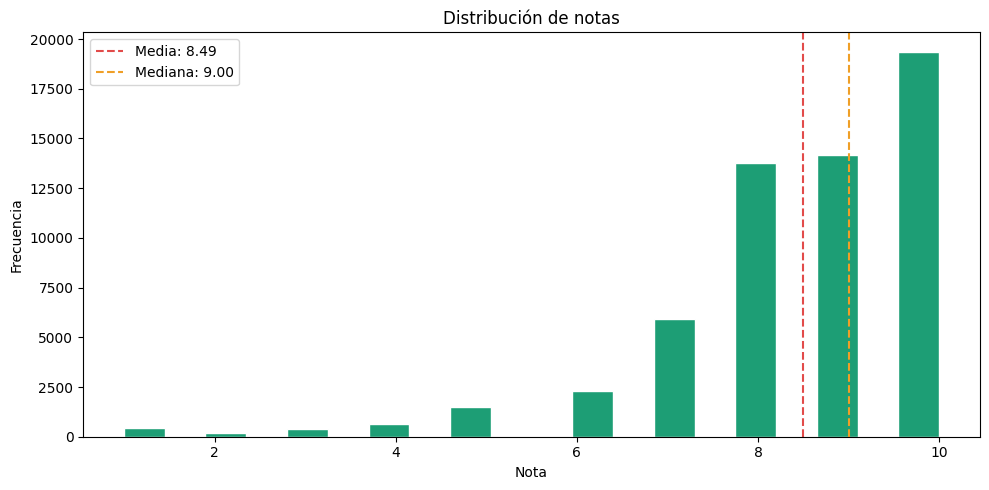

In [ ]:
print("=== DISTRIBUCIÓN DE NOTAS ===")
print(df_comentarios["nota"].value_counts(normalize=True).sort_index().round(4))
print(f"\nMedia:   {df_comentarios['nota'].mean():.2f}")
print(f"Mediana: {df_comentarios['nota'].median():.2f}")
print(f"Std:     {df_comentarios['nota'].std():.2f}")

# Histograma
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_comentarios["nota"], bins=20, color="#1D9E75", edgecolor="white")
ax.axvline(df_comentarios["nota"].mean(), color="#E24B4A", linestyle="--",
           label=f"Media: {df_comentarios['nota'].mean():.2f}")
ax.axvline(df_comentarios["nota"].median(), color="#EF9F27", linestyle="--",
           label=f"Mediana: {df_comentarios['nota'].median():.2f}")
ax.set_title("Distribución de notas")
ax.set_xlabel("Nota")
ax.set_ylabel("Frecuencia")
ax.legend()

plt.tight_layout()
plt.show()

Podemos ver que las notas están sesgadas, no solo a través de las proporciones, sino que también en base a los estadísticos calculados.

La media es de 8.49, lo que es muy alto y la mediana en 9.00, es decir, la mitad de las reseñas tienen nota 9 o más. Además, la desviación típica es de 1.63, lo que nos indica que las notas no varían mucho, están acumuladas arriba.

=== RESEÑAS POR HOTEL ===
nombre_del_hotel
venecia plaza centro                          9877
casual vintage valencia                       7317
the river hostel                              6534
only you hotel valencia                       5337
nh valencia las ciencias                      4708
silken puerta valencia                        4412
ilunion aqua 3                                4120
sweet hotel renasa                            3991
casual del cine valencia by casual hoteles    3962
meliá valencia                                3354
hotel las arenas balneario resort             3000
barceló valencia                              2108
Name: count, dtype: int64


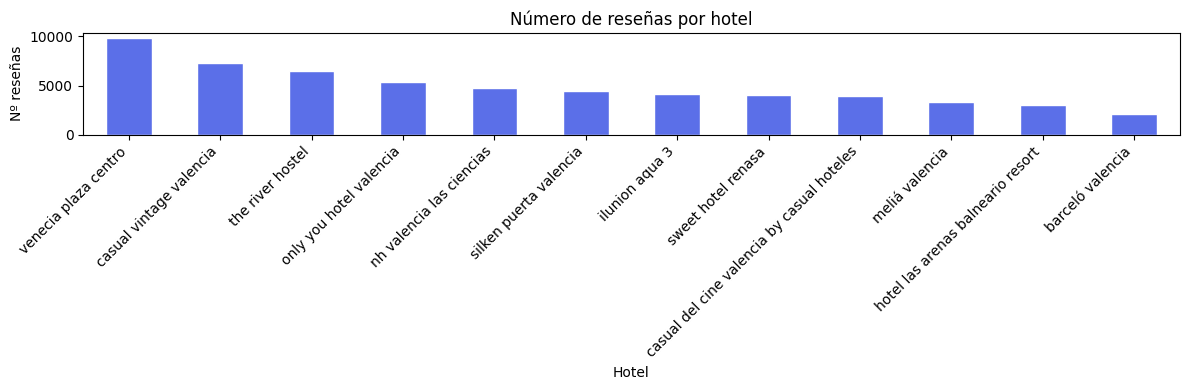

In [ ]:
# Reseñas por hotel
resenas_por_hotel = df_comentarios["nombre_del_hotel"].value_counts()
print("=== RESEÑAS POR HOTEL ===")
print(resenas_por_hotel)

resenas_por_hotel.plot(kind="bar", figsize=(12, 4), color="#5B6FE8", edgecolor="white")
plt.title("Número de reseñas por hotel")
plt.xlabel("Hotel")
plt.ylabel("Nº reseñas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

El hotel que más reseñas tiene es Venecia Plaza Centro que debe de tener tantos por a ubicación en la que está.

In [ ]:
# Longitud de los comentarios
df_comentarios["len_general"] = df_comentarios["comentario_general"].fillna("").apply(len)
df_comentarios["len_positivo"] = df_comentarios["positivo"].fillna("").apply(len)
df_comentarios["len_negativo"] = df_comentarios["negativo"].fillna("").apply(len)

print("=== LONGITUD MEDIA DE COMENTARIOS ===")
print(f"comentario_general: {df_comentarios['len_general'].mean():.0f} caracteres")
print(f"positivo:           {df_comentarios['len_positivo'].mean():.0f} caracteres")
print(f"negativo:           {df_comentarios['len_negativo'].mean():.0f} caracteres")

=== LONGITUD MEDIA DE COMENTARIOS ===
comentario_general: 18 caracteres
positivo:           59 caracteres
negativo:           45 caracteres


En general se ve que se suelen alargar más diciendo cosas positivas que negativas.

##Creación de las tres clases por el sesgo:
- Clase 0 → nota ≤ 6 (baja, ~8% del dataset)
- Clase 1 → nota 7–8 (media, ~27%)
- Clase 2 → nota 9–10 (alta, ~65%)

In [7]:
# <-----------
def categorizar_nota(nota):
    if nota <= 6:   return 0   # baja
    elif nota <= 8: return 1   # media
    else:           return 2   # alta

df_comentarios["clase"] = df_comentarios["nota"].apply(categorizar_nota)

print("=== DISTRIBUCIÓN DE CLASES ===")
print(df_comentarios["clase"].value_counts(normalize=True).sort_index().round(4))

=== DISTRIBUCIÓN DE CLASES ===
clase
0    0.0930
1    0.3356
2    0.5714
Name: proportion, dtype: float64


De este análisis destaca que:

1. comentario_general tiene solo 18 caracteres de media, mientras que las columnas positivo (59) y negativo (45) tienen mucho más texto. Esto significa que para el modelo se usarán positivo y negativo como input principal, no comentario_general.
2. negativo tiene 35.396 nulos — el 60% del dataset
Tiene sentido: si alguien está contento no escribe nada en el campo negativo. Hay que rellenarlo con string vacío, no eliminarlo.
3. positivo tiene 27.493 nulos — el 47%
Mismo caso. Hay que rellenarlo también.

In [8]:
# <-----------

# 1 — Rellenar nulos de texto con string vacío
# Los nulos en positivo/negativo no son errores, es que el usuario
# no escribió nada. Los rellenamos con "" para no perder la fila entera.
df_comentarios["comentario_general"] = df_comentarios["comentario_general"].fillna("")
df_comentarios["positivo"]           = df_comentarios["positivo"].fillna("")
df_comentarios["negativo"]           = df_comentarios["negativo"].fillna("")

# 2 — Eliminar notas raras (6.5 y 7.1)
# Aparecían en la distribución con proporción ~0.0000
# Son 2-3 filas con error de entrada, las eliminamos
df_comentarios = df_comentarios[~df_comentarios["nota"].isin([6.5, 7.1])]

# 3 — Crear el texto unificado para pasarle a BETO
# Concatenamos las 3 columnas de texto en una sola, le ponemos etiquetas para que el modelo sepa qué es cada parte
df_comentarios["texto_modelo"] = (
    "positivo: " + df_comentarios["positivo"] + " | " +
    "negativo: " + df_comentarios["negativo"] + " | " +
    "general: "  + df_comentarios["comentario_general"]
)

#**PASO 1: ANÁLISIS DE SENTIMIENTO**

In [9]:
# <-----------
analyzer = create_analyzer(task="sentiment", lang="es")

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [ ]:
# Prueba rápida para ver cómo funciona
test = analyzer.predict("La habitación estaba sucia y el servicio fue horrible")
print(f"\nEjemplo negativo: {test}")

test2 = analyzer.predict("Todo perfecto, repetiría sin duda")
print(f"Ejemplo positivo: {test2}")


Ejemplo negativo: AnalyzerOutput(output=NEG, probas={NEG: 0.968, NEU: 0.028, POS: 0.004})
Ejemplo positivo: AnalyzerOutput(output=POS, probas={POS: 0.822, NEU: 0.166, NEG: 0.012})


In [11]:
# <-----------
# Definimos la función get_sentiment que nos da el sentimiento
def get_sentiment(texto):
    if texto.strip() == "":
        return 0.0, 0.0, 1.0  # si no hay texto → neutro
    try:
        result = analyzer.predict(texto)
        return result.probas["POS"], result.probas["NEG"], result.probas["NEU"]
    except:
        return 0.0, 0.0, 1.0

In [ ]:
# Prueba con 100 filas primero
muestra = df_comentarios.head(100).copy()
muestra[["sent_pos", "sent_neg", "sent_neu"]] = muestra["texto_modelo"].progress_apply(
    lambda x: pd.Series(get_sentiment(x))
)
print(muestra[["nota", "sent_pos", "sent_neg", "sent_neu"]].head(10))

100%|██████████| 100/100 [00:39<00:00,  2.52it/s]

   nota  sent_pos  sent_neg  sent_neu
0  10.0  0.927903  0.006858  0.065239
1   9.0  0.237485  0.057433  0.705082
2   9.0  0.205015  0.044845  0.750140
3  10.0  0.215868  0.038916  0.745215
4  10.0  0.413458  0.058927  0.527615
5  10.0  0.909435  0.010315  0.080250
6  10.0  0.063020  0.191931  0.745049
7   9.0  0.962202  0.004199  0.033599
8  10.0  0.760321  0.033210  0.206469
9   9.0  0.889113  0.010344  0.100543


- sent_pos → probabilidad de que el texto sea positivo
- sent_neg → probabilidad de que el texto sea negativo
- sent_neu → probabilidad de que el texto sea neutro

La fila 6 tiene nota 10 y sent_pos 0.06, sent_neg 0.19, sent_neu 0.74. El modelo ve el texto como neutro pero la persona puso 10. Esto es una contradicción, ya que alguien que escribe poco o de forma neutra luego pone muy buena nota.

In [ ]:
LOTE = 1000  # filas por lote
ARCHIVO = "comentarios_sentiment.csv"

# Si ya existe el archivo (por si Colab se ha desconectado),
# cargamos lo que ya estaba hecho y continuamos desde ahí
if os.path.exists(ARCHIVO):
    df_hecho = pd.read_csv(ARCHIVO)
    inicio = len(df_hecho)
    print(f"Retomando desde fila {inicio}...")
else:
    df_hecho = pd.DataFrame()
    inicio = 0
    print("Empezando desde el principio...")

print(f"Filas totales: {len(df_comentarios)} | Faltan: {len(df_comentarios) - inicio}")

Retomando desde fila 46000...
Filas totales: 58718 | Faltan: 12718


In [ ]:
# Bucle por lotes
for i in tqdm(range(inicio, len(df_comentarios), LOTE)):

    # Coger el lote
    lote = df_comentarios.iloc[i:i+LOTE].copy()

    # Aplicar sentiment
    lote[["sent_pos", "sent_neg", "sent_neu"]] = lote["texto_modelo"].apply(
        lambda x: pd.Series(get_sentiment(x))
    )

    # Guardar el lote en el CSV
    if i == 0:
        lote.to_csv(ARCHIVO, index=False)  # primera vez → crear archivo
    else:
        lote.to_csv(ARCHIVO, mode="a", header=False, index=False)  # resto → añadir

print("✅ Sentiment calculado y guardado en", ARCHIVO)

100%|██████████| 13/13 [40:47<00:00, 188.24s/it]

✅ Sentiment calculado y guardado en comentarios_sentiment.csv


In [ ]:
# Cargar el resultado final
df_comentarios = pd.read_csv(ARCHIVO)
print(f"Filas totales con sentiment: {len(df_comentarios)}")
print(df_comentarios[["nota", "sent_pos", "sent_neg", "sent_neu"]].head())

Filas totales con sentiment: 58718
   nota  sent_pos  sent_neg  sent_neu
0  10.0  0.927903  0.006858  0.065239
1   9.0  0.237485  0.057433  0.705082
2   9.0  0.205015  0.044845  0.750140
3  10.0  0.215868  0.038916  0.745215
4  10.0  0.413458  0.058927  0.527615


In [ ]:
# Guardar en /content
df_comentarios.to_csv("/content/comentarios_sentiment.csv", index=False)

✅ Guardado con 58718 filas


In [10]:
# <-----------

df_sentimientos = pd.read_csv("/content/comentarios_sentiment.csv") # <-CUIDADO CON LA RUTA

In [11]:
# Correlación de spearman: sentimentos vs nota real VEAMOS QUE SENTIMIENTOS AYUDAN MÁS A PREDECIR
corr_pos, p_pos = stats.spearmanr(df_sentimientos["sent_pos"], df_sentimientos["nota"])
corr_neg, p_neg = stats.spearmanr(df_sentimientos["sent_neg"], df_sentimientos["nota"])
corr_neu, p_neu = stats.spearmanr(df_sentimientos["sent_neu"], df_sentimientos["nota"])

print("=== CORRELACIÓN SPEARMAN: SENTIMENT vs NOTA ===")
print(f"sent_pos ↔ nota: {corr_pos:.3f} (p={p_pos:.4f})")
print(f"sent_neg ↔ nota: {corr_neg:.3f} (p={p_neg:.4f})")
print(f"sent_neu ↔ nota: {corr_neu:.3f} (p={p_neu:.4f})")

=== CORRELACIÓN SPEARMAN: SENTIMENT vs NOTA ===
sent_pos ↔ nota: 0.354 (p=0.0000)
sent_neg ↔ nota: -0.174 (p=0.0000)
sent_neu ↔ nota: -0.040 (p=0.0000)


El sentimiento positivo es el que mejor predice la nota real (r=0.354), mientras que el negativo tiene un efecto inverso pero más débil (r=-0.174). El sentimiento neutro prácticamente no aporta nada (r=-0.040). Esto significa que el texto de las reseñas sí contiene información útil para predecir la nota, pero no es suficiente por sí solo, lo que justifica usar BETO en el Paso 2.

In [12]:
#  Perfil de sentimiento por hotel

perfil_hotel = df_sentimientos.groupby("nombre_del_hotel")[["sent_pos","sent_neg","sent_neu","nota"]].mean().round(3)
print("=== SENTIMIENTO MEDIO POR HOTEL ===")
print(perfil_hotel.sort_values("sent_pos", ascending=False))

=== SENTIMIENTO MEDIO POR HOTEL ===
                                            sent_pos  sent_neg  sent_neu  \
nombre_del_hotel                                                           
venecia plaza centro                           0.439     0.076     0.485   
casual vintage valencia                        0.393     0.117     0.489   
only you hotel valencia                        0.383     0.091     0.525   
hotel las arenas balneario resort              0.378     0.134     0.488   
casual del cine valencia by casual hoteles     0.373     0.121     0.506   
barceló valencia                               0.358     0.120     0.522   
the river hostel                               0.325     0.130     0.545   
silken puerta valencia                         0.298     0.130     0.572   
meliá valencia                                 0.284     0.163     0.553   
sweet hotel renasa                             0.284     0.146     0.570   
ilunion aqua 3                                 0.254

El ranking de hoteles por sentimiento positivo medio coincide casi exactamente con el ranking por nota media real. Esto sugiere que el sentimiento agregado de las reseñas es un buen indicador de la calidad percibida del hotel.

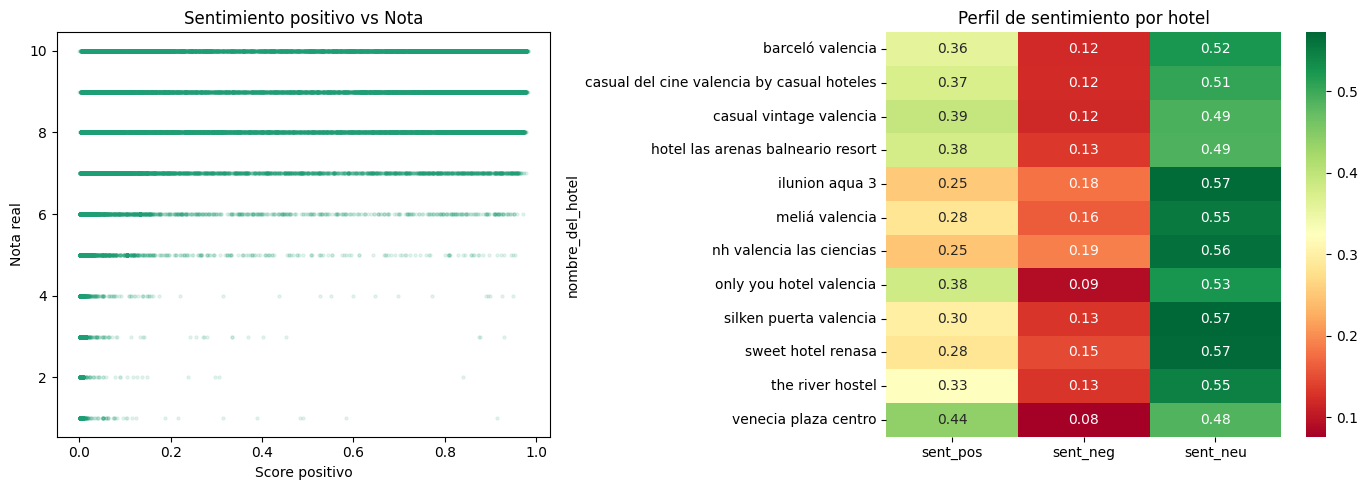

In [13]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_sentimientos["sent_pos"], df_sentimientos["nota"],
                alpha=0.1, color="#1D9E75", s=5)
axes[0].set_xlabel("Score positivo")
axes[0].set_ylabel("Nota real")
axes[0].set_title("Sentimiento positivo vs Nota")

perfil_hotel = df_sentimientos.groupby("nombre_del_hotel")[["sent_pos","sent_neg","sent_neu"]].mean().round(3)
sns.heatmap(perfil_hotel, annot=True, fmt=".2f", cmap="RdYlGn", ax=axes[1])
axes[1].set_title("Perfil de sentimiento por hotel")

plt.tight_layout()
plt.show()

- *Scatter (Sentimiento positivo vs Nota real)*:

Las notas forman líneas horizontales (1, 2, 3... 10) porque son valores discretos. Lo que hay que mirar es hacia dónde se desplazan los puntos en cada línea, en las notas altas (9 y 10) los puntos se concentran más hacia la derecha (sent_pos alto), mientras que en las notas bajas (1 y 2) los puntos están más a la izquierda (sent_pos bajo). Esto confirma que a mayor sentimiento positivo, mayor nota, aunque hay mucho solapamiento entre líneas, lo que significa que el sentimiento solo explica una parte de la nota.

- *Heatmap (Perfil de sentimiento por hotel)*:

Cada fila es un hotel y cada columna es un tipo de sentimiento. El color verde indica valor alto y el rojo valor bajo. Lo primero que llama la atención es que la columna sent_neu es la más verde en todos los hoteles (~0.48–0.57), lo que significa que el modelo interpreta la mayoría de comentarios como neutros. Esto ocurre porque los comentarios son cortos (media 157 caracteres) y poco expresivos. La columna sent_neg es la más roja en general, con nh valencia las ciencias e ilunion aqua 3 destacando en rojo intenso (0.18–0.19), siendo los hoteles con comentarios más negativos.

#**Paso 2 — Modelo predictivo con BETO (fine-tuning)** **USO DE GPU**

In [14]:
print(f"GPU disponible: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU disponible: True
GPU: Tesla T4


In [15]:
# <-----------
df_sentimientos["clase"] = df_sentimientos["nota"].apply(categorizar_nota)

# Calcular pesos de clase
pesos = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=df_sentimientos["clase"]
)

print(f"Pesos por clase:")
print(f"  Clase 0 (baja):  {pesos[0]:.2f}")
print(f"  Clase 1 (media): {pesos[1]:.2f}")
print(f"  Clase 2 (alta):  {pesos[2]:.2f}")

Pesos por clase:
  Clase 0 (baja):  3.58
  Clase 1 (media): 0.99
  Clase 2 (alta):  0.58


- Clase 0 (baja) → el modelo penaliza x3.58 equivocarse en notas bajas
- Clase 1 (media) → peso neutro, es la clase más equilibrada
- Clase 2 (alta) → se penaliza menos porque hay muchísimos ejemplos

In [17]:
#Entrenamos el modelo:
X_train, X_test, y_train, y_test = train_test_split(
    df_sentimientos["texto_modelo"],
    df_sentimientos["clase"],
    test_size=0.2,
    random_state=42,
    stratify=df_sentimientos["clase"]  # mantiene la proporción de clases
)

print(f"Train: {len(X_train)} filas")
print(f"Test:  {len(X_test)} filas")
print(f"\nDistribución clases en train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f"\nDistribución clases en test:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Train: 46974 filas
Test:  11744 filas

Distribución clases en train:
clase
0    0.093
1    0.336
2    0.571
Name: proportion, dtype: float64

Distribución clases en test:
clase
0    0.093
1    0.336
2    0.571
Name: proportion, dtype: float64


In [19]:
# Cargar BETO y tokenizar

tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

# Tokenizar train y test
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

print(f"✅ Tokenización completada")
print(f"Shape input_ids train: {train_encodings['input_ids'].shape}")
print(f"Shape input_ids test:  {test_encodings['input_ids'].shape}")

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

✅ Tokenización completada
Shape input_ids train: torch.Size([46974, 256])
Shape input_ids test:  torch.Size([11744, 256])


In [21]:
# Crear Dataset de PyTorch
class HotelDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = HotelDataset(train_encodings, y_train.reset_index(drop=True))
test_dataset  = HotelDataset(test_encodings,  y_test.reset_index(drop=True))

print(f"✅ Dataset creado")
print(f"Train: {len(train_dataset)} ejemplos")
print(f"Test:  {len(test_dataset)} ejemplos")

✅ Dataset creado
Train: 46974 ejemplos
Test:  11744 ejemplos


In [22]:
# Cargar modelo BETO
from transformers import AutoModelForSequenceClassification

modelo = AutoModelForSequenceClassification.from_pretrained(
    "dccuchile/bert-base-spanish-wwm-cased",
    num_labels=3
)

modelo = modelo.to("cuda")
print(f"✅ Modelo cargado en GPU")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

✅ Modelo cargado en GPU


In [24]:
# Entrenamiento
# Pesos de clase en GPU
pesos_tensor = torch.tensor(pesos, dtype=torch.float).to("cuda")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

# Optimizador y scheduler
optimizer = AdamW(modelo.parameters(), lr=2e-5)
num_epochs = 3
scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=100,
    num_training_steps=len(train_loader) * num_epochs
)

# Loss con pesos de clase
loss_fn = nn.CrossEntropyLoss(weight=pesos_tensor)

print(f"✅ Configuración lista")
print(f"Pasos por época: {len(train_loader)}")
print(f"Total pasos: {len(train_loader) * num_epochs}")

✅ Configuración lista
Pasos por época: 2936
Total pasos: 8808


In [25]:
# Bucle de entrenamiento
for epoch in range(num_epochs):
    modelo.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Época {epoch+1}/{num_epochs}"):
        batch = {k: v.to("cuda") for k, v in batch.items()}

        outputs = modelo(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=batch.get("token_type_ids")
        )

        loss = loss_fn(outputs.logits, batch["labels"])
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    print(f"Época {epoch+1} — Loss media: {total_loss/len(train_loader):.4f}")

print("✅ Entrenamiento completado")

Época 1/3: 100%|██████████| 2936/2936 [34:42<00:00,  1.41it/s]


Época 1 — Loss media: 0.2655


Época 2/3: 100%|██████████| 2936/2936 [34:27<00:00,  1.42it/s]


Época 2 — Loss media: 0.1917


Época 3/3: 100%|██████████| 2936/2936 [34:25<00:00,  1.42it/s]

Época 3 — Loss media: 0.1382
✅ Entrenamiento completado


In [26]:
# Guardar el modelo entrenado
modelo.save_pretrained("/content/modelo_beto_hoteles")
tokenizer.save_pretrained("/content/modelo_beto_hoteles")
print("✅ Modelo guardado")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modelo guardado


In [27]:
# Comprimir y descargar
!zip -r /content/modelo_beto_hoteles.zip /content/modelo_beto_hoteles

from google.colab import files
files.download("/content/modelo_beto_hoteles.zip")

  adding: content/modelo_beto_hoteles/ (stored 0%)
  adding: content/modelo_beto_hoteles/model.safetensors (deflated 7%)
  adding: content/modelo_beto_hoteles/config.json (deflated 54%)
  adding: content/modelo_beto_hoteles/tokenizer_config.json (deflated 45%)
  adding: content/modelo_beto_hoteles/tokenizer.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# <-----------

# CARGAR EL MODELO ENTRENADO (sin reentrenar)
from transformers import AutoModelForSequenceClassification, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("/content/modelo_beto_hoteles")
modelo = AutoModelForSequenceClassification.from_pretrained("/content/modelo_beto_hoteles")
modelo = modelo.to("cuda")
print("✅ Modelo cargado sin reentrenar")

In [28]:
# Evaluación
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

modelo.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluando"):
        batch = {k: v.to("cuda") for k, v in batch.items()}
        outputs = modelo(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=batch.get("token_type_ids")
        )
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

print("=== MÉTRICAS ===")
print(classification_report(
    all_labels, all_preds,
    target_names=["baja (0)", "media (1)", "alta (2)"]
))

Evaluando: 100%|██████████| 734/734 [02:39<00:00,  4.60it/s]

=== MÉTRICAS ===
              precision    recall  f1-score   support

    baja (0)       0.83      0.90      0.86      1093
   media (1)       0.85      0.90      0.87      3941
    alta (2)       0.96      0.92      0.94      6710

    accuracy                           0.91     11744
   macro avg       0.88      0.90      0.89     11744
weighted avg       0.91      0.91      0.91     11744



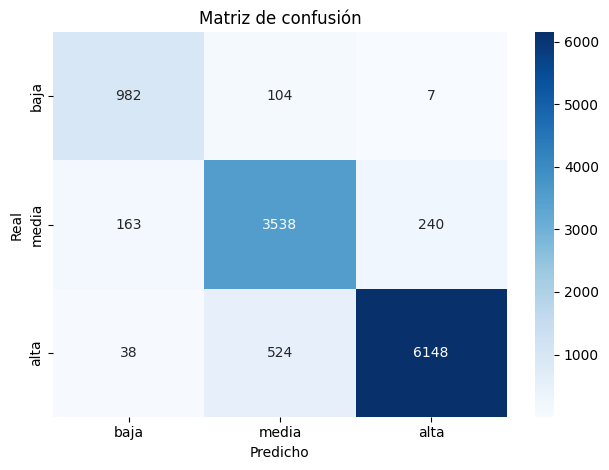

In [29]:
# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["baja", "media", "alta"],
            yticklabels=["baja", "media", "alta"])
plt.title("Matriz de confusión")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

La *accuracy* de 0.91, nos indica que clasifica correctamente el 91% de las reseñas, y un *F1-score macro* de 0.89, refleja un comportamiento equilibrado entre las tres clases analizadas.

Por otro lado, el análisis por categorías muestra resultados especialmente positivos en la clase baja (F1 = 0.86), a pesar de representar únicamente el 9% del conjunto de datos, lo que confirma que el uso de pesos de clase balanceados ha sido efectivo para reducir el impacto del desbalanceo. Además, la clase media obtuvo un F1 de 0.87, mientras que la clase alta alcanzó un F1 de 0.94, siendo esta la categoría con mejor rendimiento debido, en parte, a una mayor cantidad de ejemplos disponibles durante el entrenamiento.

La matriz de confusión muestra que la mayoría de las predicciones correctas se concentran en la diagonal principal, con 982, 3538 y 6148 aciertos para las clases baja, media y alta respectivamente. Los errores más frecuentes se producen entre las clases pegadas, especialmente entre las categorías media y alta, con 524 reseñas clasificadas como medias cuando realmente eran altas y 240 clasificadas como altas cuando correspondían a la clase media. Esto no nos sorprende, ya que la diferencia entre puntuaciones cercanas, como un 8 y un 9, puede ser subjetiva incluso para los propios usuarios. Sin embargo, el modelo apenas confunde los extremos, sólo hay 7 casos en los que una reseña negativa fue clasificada como positiva, lo que demuestra una buena capacidad para diferenciar opiniones claramente negativas de las claramente positivas.


## Paso 3 — Agregación por hotel

In [30]:
#  Predecir sobre todo el dataset

from torch.utils.data import DataLoader

# Tokenizar todo el dataset completo
all_encodings = tokenizer(
    list(df_sentimientos["texto_modelo"]),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

# Crear dataset sin etiquetas
class HotelDatasetPredict(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}

all_dataset = HotelDatasetPredict(all_encodings)
all_loader  = DataLoader(all_dataset, batch_size=16, shuffle=False)

# Predecir
modelo.eval()
predicciones = []

with torch.no_grad():
    for batch in tqdm(all_loader, desc="Prediciendo"):
        batch = {k: v.to("cuda") for k, v in batch.items()}
        outputs = modelo(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=batch.get("token_type_ids")
        )
        preds = torch.argmax(outputs.logits, dim=1)
        predicciones.extend(preds.cpu().numpy())

df_sentimientos["clase_predicha"] = predicciones
print(f"✅ Predicciones generadas: {len(predicciones)}")
print(df_sentimientos[["nombre_del_hotel", "nota", "clase", "clase_predicha"]].head(10)) #son las 10 primeras predicciones de las reseñas de los comentarios

Prediciendo: 100%|██████████| 3670/3670 [14:26<00:00,  4.23it/s]

✅ Predicciones generadas: 58718
   nombre_del_hotel  nota  clase  clase_predicha
0  barceló valencia  10.0      2               2
1  barceló valencia   9.0      2               1
2  barceló valencia   9.0      2               2
3  barceló valencia  10.0      2               2
4  barceló valencia  10.0      2               2
5  barceló valencia  10.0      2               2
6  barceló valencia  10.0      2               2
7  barceló valencia   9.0      2               2
8  barceló valencia  10.0      2               2
9  barceló valencia   9.0      2               2


In [31]:
# Mapear clase predicha a valor numérico para poder hacer media
mapa_clase = {0: 1, 1: 2, 2: 3}  # baja=1, media=2, alta=3

df_sentimientos["clase_predicha_num"] = df_sentimientos["clase_predicha"].map(mapa_clase)

# Agrupar por hotel
resumen_hoteles = df_sentimientos.groupby("nombre_del_hotel").agg(
    nota_media_real    = ("nota", "mean"),
    clase_predicha_media = ("clase_predicha_num", "mean"),
    total_resenas      = ("nota", "count")
).round(3).sort_values("nota_media_real", ascending=False)

print("=== RESUMEN POR HOTEL ===")
print(resumen_hoteles.to_string())

=== RESUMEN POR HOTEL ===
                                            nota_media_real  clase_predicha_media  total_resenas
nombre_del_hotel                                                                                
only you hotel valencia                               9.309                 2.794           5337
venecia plaza centro                                  9.069                 2.699           9876
barceló valencia                                      8.764                 2.566           2108
meliá valencia                                        8.614                 2.517           3354
hotel las arenas balneario resort                     8.475                 2.454           3000
casual vintage valencia                               8.415                 2.409           7317
silken puerta valencia                                8.414                 2.418           4412
the river hostel                                      8.263                 2.368           6534
casu

In [32]:
corr, p = stats.spearmanr(
    resumen_hoteles["nota_media_real"],
    resumen_hoteles["clase_predicha_media"]
)

print(f"Correlación Spearman (nota real vs clase predicha): {corr:.3f}")
print(f"P-valor: {p:.4f}")

Correlación Spearman (nota real vs clase predicha): 0.993
P-valor: 0.0000


In [36]:
# Convertir clase predicha a nota estimada

# La clase predicha media está entre 1 y 3
# La nota real está entre 0 y 10
# Hacemos una interpolación lineal para convertir

def clase_a_nota(clase_media):
    # clase 1 (baja)  → nota media de la clase 0: notas ≤6, media ~4.5
    # clase 2 (media) → nota media de la clase 1: notas 7-8, media ~7.5
    # clase 3 (alta)  → nota media de la clase 2: notas 9-10, media ~9.5
    if clase_media <= 1.5:
        return 4.5
    elif clase_media <= 2.5:
        # interpolación entre 4.5 y 7.5
        t = (clase_media - 1.5)
        return 4.5 + t * 3.0
    else:
        # interpolación entre 7.5 y 9.5
        t = (clase_media - 2.5)
        return 7.5 + t * 2.0

resumen_hoteles["nota_predicha"] = resumen_hoteles["clase_predicha_media"].apply(clase_a_nota).round(2)

print("=== NOTA REAL vs NOTA PREDICHA ===")
print(resumen_hoteles[["nota_media_real", "nota_predicha", "total_resenas"]].to_string())

=== NOTA REAL vs NOTA PREDICHA ===
                                            nota_media_real  nota_predicha  total_resenas
nombre_del_hotel                                                                         
only you hotel valencia                               9.309           8.09           5337
venecia plaza centro                                  9.069           7.90           9876
barceló valencia                                      8.764           7.63           2108
meliá valencia                                        8.614           7.53           3354
hotel las arenas balneario resort                     8.475           7.36           3000
casual vintage valencia                               8.415           7.23           7317
silken puerta valencia                                8.414           7.25           4412
the river hostel                                      8.263           7.10           6534
casual del cine valencia by casual hoteles            8.240      

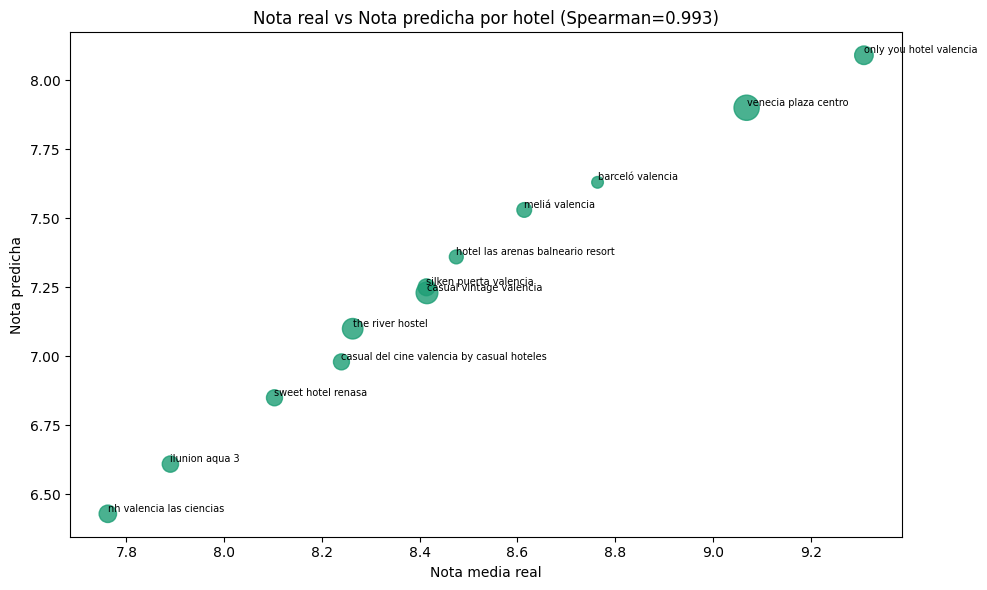

In [37]:
# Visualización final
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(resumen_hoteles["nota_media_real"],
           resumen_hoteles["nota_predicha"],
           s=resumen_hoteles["total_resenas"]/30,  # tamaño = nº reseñas
           color="#1D9E75", alpha=0.8)

# Etiqueta de cada hotel
for idx, row in resumen_hoteles.iterrows():
    ax.annotate(idx,
                (row["nota_media_real"], row["nota_predicha"]),
                fontsize=7, ha="left", va="bottom")

ax.set_xlabel("Nota media real")
ax.set_ylabel("Nota predicha")
ax.set_title(f"Nota real vs Nota predicha por hotel (Spearman=0.993)")

plt.tight_layout()
plt.show()